# Experimento 5 (nonadditive) — Efecto del término HSIC (beta) en KAN/KAAM sobre Sachs, ruido no aditivo

Variante de `sachs_hsic_beta.ipynb` que genera los datos Sachs con
`structural_equations['nonadditive']` (`src/datasets/sachs.py::get_structural_equations_sachs`) en vez
de `['additive']`. En la variante no aditiva el ruido de cada nodo no se suma al final de la red, sino
que se concatena como una entrada mas de la red (junto con los padres) antes de la capa final -- ver
`weights_nonadditive`, dimensionada con `in_deg+1` columnas -- por lo que la relacion entre ruido y
salida deja de ser un simple desplazamiento aditivo. `ExperimentationModel`/`GeneralNoiseModel` en
`sachs.py` ya soportan esta forma sin ningun cambio adicional.

Se mantiene exactamente la misma estructura que `sachs_hsic_beta.ipynb`: comparacion de
`train_loss = alpha_weight * NMSE + beta_weight * nHSIC` barriendo `beta_weight` de 0.1 a 0.8 sobre
**20 semillas** para kan y kaam por separado, seleccion de la beta optima (minimo `rf_acc_obs` medio)
por familia, y comparacion final de 6 modelos (`kan`, `kaam`, `kan_hsic`, `kaam_hsic`, `dbcm`, `flow`)
sobre una unica semilla fija (`seed=42`). **ANM queda excluido.**

**Importante -- hiperparametros no re-buscados:** `kan_best_params`/`kaam_best_params`/
`dbcm_best_params`/`flow_best_params` son los mismos valores ya fijados en `sachs_hsic_beta.ipynb`,
encontrados por una busqueda de `get_best_hyperparams` sobre datos **aditivos**
(`notebooks/alejandro/sachs_analysis.ipynb`). No se ha repetido la busqueda para el caso no aditivo
-- se asume esta limitacion conocida en vez de entrenar una busqueda completa por nodo.

Todos los resultados se guardan bajo un experimento separado (`sachs_hsic_nonadditive`) para no
mezclarse ni sobrescribir los resultados aditivos de `sachs_hsic_beta.ipynb`.

In [1]:
import os
import sys
import pickle
import time
from copy import deepcopy

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

import numpy as np
import torch
import pandas as pd
import networkx as nx
import sympy
from joblib import Parallel, delayed
from tqdm import tqdm
from tabulate import tabulate
import matplotlib.pyplot as plt

from dowhy import gcm

from models.factory import create_model_from_graph
from models.flow import causalflow_model
from models.kan import symbolic_kan_regressor
from utils.metrics import mmd, rf
from utils.paths import get_experiment_paths
from datasets.sachs import (
    ExperimentationModel,
    get_structural_equations_sachs,
    graph_sachs,
    noises_distr,
)

n_jobs = 16  # nucleos disponibles: usado tanto para el barrido de beta como para las evaluaciones intervencionales


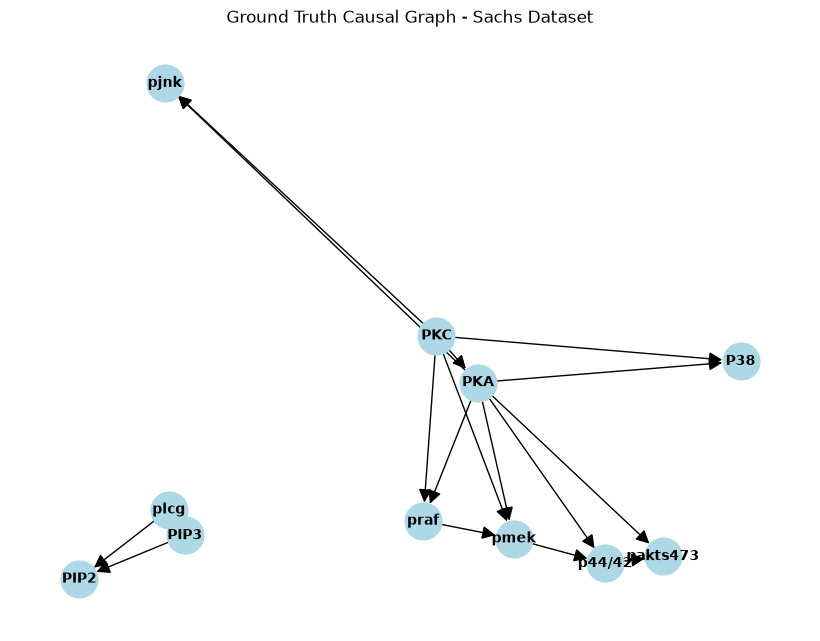

In [2]:
# Show the ground truth graph
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(graph_sachs, seed=42)
nx.draw(graph_sachs, pos, with_labels=True, node_size=700, node_color='lightblue', font_size=10, font_weight='bold', arrowsize=20)
plt.title("Ground Truth Causal Graph - Sachs Dataset")
plt.show()


In [3]:
# Verificacion de que todos los nodos del grafo Sachs son continuos (ver src/datasets/sachs.py):
# el ruido de cada nodo es ScipyDistribution sobre scipy.stats.norm, y las ecuaciones estructurales
# (basadas en silu) producen salidas reales -- no hay ningun nodo discreto/categorico.
print("Verificacion de continuidad de las variables del grafo Sachs:\n")
for node in sorted(graph_sachs.nodes):
    dist = noises_distr[node]
    print(f"  {node:10s} -> ruido: {type(dist).__name__} sobre scipy.stats.norm (continua)")

all_continuous = all(isinstance(noises_distr[n], gcm.ScipyDistribution) for n in graph_sachs.nodes)
print(f"\nTotal de nodos: {graph_sachs.number_of_nodes()}")
print(f"Todos los nodos son continuos: {all_continuous}")
assert all_continuous, "Se esperaba que todos los nodos de Sachs fuesen continuos"


Verificacion de continuidad de las variables del grafo Sachs:

  P38        -> ruido: ScipyDistribution sobre scipy.stats.norm (continua)
  PIP2       -> ruido: ScipyDistribution sobre scipy.stats.norm (continua)
  PIP3       -> ruido: ScipyDistribution sobre scipy.stats.norm (continua)
  PKA        -> ruido: ScipyDistribution sobre scipy.stats.norm (continua)
  PKC        -> ruido: ScipyDistribution sobre scipy.stats.norm (continua)
  p44/42     -> ruido: ScipyDistribution sobre scipy.stats.norm (continua)
  pakts473   -> ruido: ScipyDistribution sobre scipy.stats.norm (continua)
  pjnk       -> ruido: ScipyDistribution sobre scipy.stats.norm (continua)
  plcg       -> ruido: ScipyDistribution sobre scipy.stats.norm (continua)
  pmek       -> ruido: ScipyDistribution sobre scipy.stats.norm (continua)
  praf       -> ruido: ScipyDistribution sobre scipy.stats.norm (continua)

Total de nodos: 11
Todos los nodos son continuos: True


100%|██████████| 11/11 [00:09<00:00,  1.20it/s]


Train set shape: (300, 11), Eval set shape: (300, 11), Num of interventions: 660


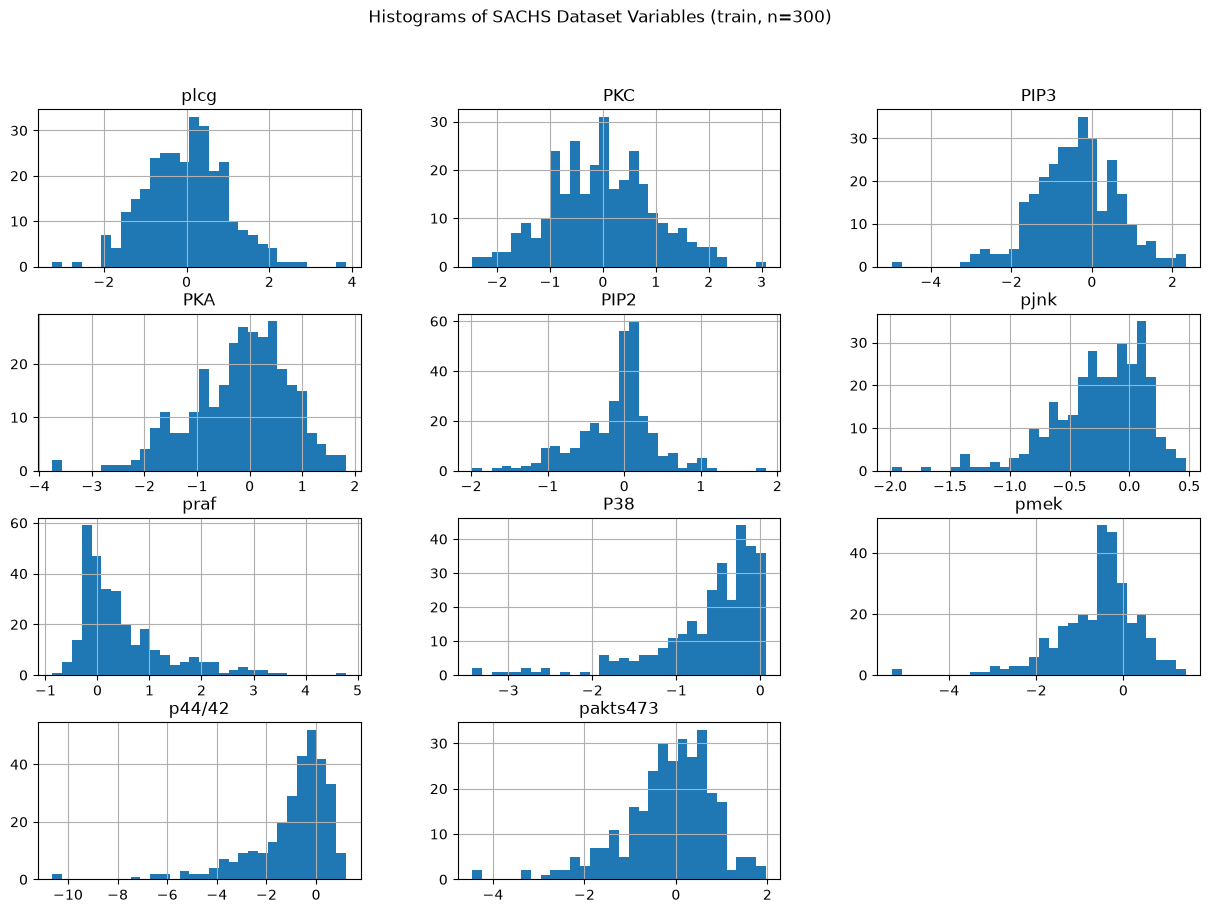

In [6]:
# Generate the SACHS dataset using the structural equations defined in datasets/sachs.py
num_samples_train = 300
num_samples_eval = 300
structural_equations = get_structural_equations_sachs()
sachs_generator = ExperimentationModel(graph_sachs, "sachs_hsic_nonadditive", structural_equations['nonadditive'], noises_distr)
np.random.seed(42)  # Set seed for repeatability
factual_train, noise_train = sachs_generator.sample(num_samples_train)
factual_eval, noise_eval = sachs_generator.sample(num_samples_eval)

cf_min_val = -3
cf_max_val = 3
cf_step = 0.1
cf_vector_values = np.arange(cf_min_val, cf_max_val, cf_step)
inter_vector = []
for node in tqdm(factual_eval.columns):
    for value in list(cf_vector_values):
        inter_vector.append((node, value, sachs_generator.get_counterfactuals({node: lambda x: value}, noise_eval)[factual_eval.columns]))

print(f'Train set shape: {factual_train.shape}, Eval set shape: {factual_eval.shape}, Num of interventions: {len(inter_vector)}')

paths = get_experiment_paths('sachs_hsic_nonadditive')
results_bdir = str(paths.root)
images_dir = str(paths.images)
samples_dir = str(paths.samples)
figures_dir = str(paths.figures)
data_dir = str(paths.data)

factual_train.to_csv(os.path.join(data_dir, 'sachs_factual_train.csv'), index=False)
factual_eval.to_csv(os.path.join(data_dir, 'sachs_factual_eval.csv'), index=False)

with open(os.path.join(data_dir, 'sachs_interventions_eval.pkl'), 'wb') as f:
    pickle.dump(inter_vector, f, protocol=pickle.HIGHEST_PROTOCOL)

# Show a histogram of all the variables in the dataset (train)
factual_train.hist(bins=30, figsize=(15, 10))
plt.suptitle("Histograms of SACHS Dataset Variables (train, n=300)")
plt.show()


## Hiperparametros fijos (best params ya encontrados)

Sin busqueda de hiperparametros: se usan directamente los mejores hiperparametros ya localizados
para kan, kaam, dbcm y flow sobre Sachs (salida de una busqueda previa con `get_best_hyperparams`,
limpiada de las claves de diagnostico `mmd`/`rf_acc` que no son argumentos validos de los
constructores). `kan_best_params` y `kaam_best_params` son identicos salvo en `pakts473`, donde kan
usa una configuracion multicapa (`hidden_dim=5`, `mult_kan=True`) y kaam se mantiene monocapa
(`hidden_dim=0`, `mult_kan=False`).

**Nota (nonadditive):** estos valores son los mismos encontrados para el caso aditivo -- no se ha repetido la busqueda de hiperparametros para la variante de ruido no aditivo, se reutilizan tal cual como limitacion conocida.

In [7]:
kaam_best_params = {
    "PIP3": dict(hidden_dim=0, batch_size=-1, grid=1, k=5, seed=0, lr=0.001, early_stop=True,
                 steps=10000, lamb=0.1, lamb_entropy=0.1, sparse_init=False, mult_kan=False,
                 try_gpu=False, loss="mse"),
    "PIP2": dict(hidden_dim=0, batch_size=-1, grid=5, k=5, seed=0, lr=0.0001, early_stop=True,
                 steps=10000, lamb=0.001, lamb_entropy=0.1, sparse_init=False, mult_kan=False,
                 try_gpu=False, loss="mse"),
    "PKA": dict(hidden_dim=0, batch_size=-1, grid=10, k=1, seed=0, lr=0.01, early_stop=True,
                steps=10000, lamb=0.001, lamb_entropy=0.1, sparse_init=False, mult_kan=False,
                try_gpu=False, loss="mse"),
    "pjnk": dict(hidden_dim=0, batch_size=-1, grid=10, k=1, seed=0, lr=0.01, early_stop=True,
                 steps=10000, lamb=0.001, lamb_entropy=0.1, sparse_init=False, mult_kan=False,
                 try_gpu=False, loss="mse"),
    "P38": dict(hidden_dim=0, batch_size=-1, grid=1, k=5, seed=0, lr=0.001, early_stop=True,
                steps=10000, lamb=0.1, lamb_entropy=0.1, sparse_init=False, mult_kan=False,
                try_gpu=False, loss="mse"),
    "praf": dict(hidden_dim=0, batch_size=-1, grid=5, k=5, seed=0, lr=0.01, early_stop=True,
                 steps=10000, lamb=0.1, lamb_entropy=0.1, sparse_init=False, mult_kan=False,
                 try_gpu=False, loss="mse"),
    "pmek": dict(hidden_dim=0, batch_size=-1, grid=5, k=5, seed=0, lr=0.01, early_stop=True,
                 steps=10000, lamb=0.1, lamb_entropy=0.1, sparse_init=False, mult_kan=False,
                 try_gpu=False, loss="mse"),
    "p44/42": dict(hidden_dim=0, batch_size=-1, grid=5, k=5, seed=0, lr=0.0001, early_stop=True,
                   steps=10000, lamb=0.001, lamb_entropy=0.1, sparse_init=False, mult_kan=False,
                   try_gpu=False, loss="mse"),
    "pakts473": dict(hidden_dim=0, batch_size=-1, grid=10, k=1, seed=0, lr=0.001, early_stop=True,
                      steps=10000, lamb=0.001, lamb_entropy=0.1, sparse_init=False, mult_kan=False,
                      try_gpu=False, loss="mse"),
}

kan_best_params = deepcopy(kaam_best_params)
kan_best_params["pakts473"] = dict(hidden_dim=5, batch_size=-1, grid=10, k=10, seed=0, lr=0.01,
                                    early_stop=True, steps=10000, lamb=0.001, lamb_entropy=0.1,
                                    sparse_init=False, mult_kan=True, try_gpu=False, loss="mse")

dbcm_best_params = dict(num_epochs=500, lr=0.001, batch_size=128, hidden_dim=64)

flow_best_params = dict(flow_type="CausalMAF", hidden_dims=(64, 64, 64), base_lr=0.01,
                         early_stopping_patience=30, scheduler="plateau", batch_size=256,
                         train_val_split=(0.8, 0.2), max_epochs=1000, device="cpu", bins=4)


def with_hybrid_loss(base_params, beta):
    """Devuelve una copia de base_params con loss='hybrid' y los pesos alpha/beta indicados."""
    params = deepcopy(base_params)
    for node in params:
        params[node] = {**params[node], "loss": "hybrid", "beta_weight": beta, "alpha_weight": 1 - beta}
    return params


betas = [round(0.1 * i, 1) for i in range(1, 9)]  # 0.1 .. 0.8
print(f"Betas a evaluar: {betas}")


Betas a evaluar: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]


## Barrido de beta (kan y kaam por separado, 20 semillas, paralelizado)

Para cada combinación (familia, beta, semilla) se entrena el modelo con `loss='hybrid'` (o `loss='mse'`
para el punto `Beta=0`) y se evalúa solo con métricas observacionales (`mmd_obs`, `rf_acc_obs`) --
repetir la evaluación intervencional/contrafactual completa para las 360 combinaciones sería mucho más
caro sin aportar a la selección, que solo usa estas dos métricas observacionales.

Diseño: el conjunto de **evaluación** es siempre el `factual_eval` fijo definido en la celda "Generate
the SACHS dataset" (igual para las 20 semillas, para que sean comparables entre sí); lo único que varía
por semilla es el conjunto de **entrenamiento** (`factual_train_por_seed`), generado aquí una vez por
semilla reutilizando el mismo `sachs_generator`. `Beta=0` (MSE puro) se entrena con las mismas 20
semillas -- ya no se reutiliza el `kan`/`kaam` de la sección de los 6 modelos finales (esos siguen
usando solo `seed=42`) -- para tener también su propia media ± std, comparable con el resto del barrido.

Se paraleliza a `n_jobs=16`: (2 familias x 8 betas x 20 semillas) + (2 familias x 20 semillas, para
`Beta=0`) = 320 + 40 = 360 combinaciones en total (~22.5x más que el barrido original de una sola
semilla, que solo cubría las 16 combinaciones familia x beta).

A continuacion de esta celda (antes de la seleccion de la beta optima) se entrena tambien `dbcm`/`flow` sobre las mismas 20 semillas, reutilizando el `factual_train_por_seed`, `data_dir` y `n_jobs` definidos aqui en vez de recalcularlos.

In [ ]:
beta_sweep_seeds = np.array([42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
                              52, 53, 54, 55, 56, 57, 58, 59, 60, 61])  # 20 semillas

# Un conjunto de entrenamiento distinto por semilla (mismo tamano que el factual_train de
# seed=42, 300 muestras); reutiliza el mismo sachs_generator, la evaluacion sigue siendo
# siempre el factual_eval fijo definido antes.
factual_train_por_seed = {}
for seed in beta_sweep_seeds:
    np.random.seed(int(seed))
    factual_train_por_seed[int(seed)], _ = sachs_generator.sample(num_samples_train)


def train_and_eval_run(family, beta, seed):
    """beta=None entrena el baseline (loss='mse'); beta en (0, 1) entrena con loss='hybrid'."""
    base = kan_best_params if family == "kan" else kaam_best_params
    params = deepcopy(base) if beta is None else with_hybrid_loss(base, beta)
    model = create_model_from_graph(graph_sachs, family, params=params)

    t0 = time.time()
    gcm.fit(model, data=factual_train_por_seed[seed])
    training_time = time.time() - t0

    obs_samples = gcm.draw_samples(model, num_samples=len(factual_eval))
    obs_samples = obs_samples[factual_eval.columns]
    metrics = {
        "mmd_obs": mmd(factual_eval.to_numpy(), obs_samples.to_numpy()),
        "rf_acc_obs": rf(factual_eval.to_numpy(), obs_samples.to_numpy()),
        "training_time": training_time,
    }
    return family, beta, seed, metrics


tareas = [(family, None, int(seed)) for family in ["kan", "kaam"] for seed in beta_sweep_seeds]
tareas += [(family, beta, int(seed)) for family in ["kan", "kaam"] for beta in betas for seed in beta_sweep_seeds]

out = Parallel(n_jobs=n_jobs, verbose=5)(delayed(train_and_eval_run)(family, beta, seed) for family, beta, seed in tareas)

resultados_por_semilla = {"kan": {}, "kaam": {}}
for family, beta, seed, metrics in out:
    resultados_por_semilla[family].setdefault(beta, {})[seed] = metrics

# beta=None (Beta=0, MSE puro) y beta in betas (barrido hybrid), separados para claridad.
beta0_sweep_results_por_semilla = {family: resultados_por_semilla[family][None] for family in ["kan", "kaam"]}
beta_sweep_results_por_semilla = {family: {b: resultados_por_semilla[family][b] for b in betas} for family in ["kan", "kaam"]}

# Agregado (media sobre las 20 semillas) con el MISMO esquema de antes (una fila por beta,
# sin dimension de semilla), para que la seleccion de la Beta optima (celda siguiente) y
# Resumen_Sachs.ipynb sigan funcionando sin cambios -- ahora la media es sobre 20 semillas
# en vez de un unico punto.
beta_sweep_results = {"kan": {}, "kaam": {}}
for family in ["kan", "kaam"]:
    for beta in betas:
        valores = list(beta_sweep_results_por_semilla[family][beta].values())
        beta_sweep_results[family][beta] = {
            "mmd_obs": float(np.mean([v["mmd_obs"] for v in valores])),
            "rf_acc_obs": float(np.mean([v["rf_acc_obs"] for v in valores])),
            "training_time": float(np.mean([v["training_time"] for v in valores])),
        }

for family in ["kan", "kaam"]:
    with open(os.path.join(data_dir, f"sachs_beta_sweep_{family}.pkl"), "wb") as f:
        pickle.dump(beta_sweep_results[family], f, protocol=pickle.HIGHEST_PROTOCOL)
    with open(os.path.join(data_dir, f"sachs_beta_sweep_{family}_por_semilla.pkl"), "wb") as f:
        pickle.dump(beta_sweep_results_por_semilla[family], f, protocol=pickle.HIGHEST_PROTOCOL)
    with open(os.path.join(data_dir, f"sachs_beta0_sweep_{family}_por_semilla.pkl"), "wb") as f:
        pickle.dump(beta0_sweep_results_por_semilla[family], f, protocol=pickle.HIGHEST_PROTOCOL)

for family in ["kan", "kaam"]:
    print(f"\nBarrido de beta para {family} (media +- std sobre {len(beta_sweep_seeds)} semillas):")
    valores0 = list(beta0_sweep_results_por_semilla[family].values())
    rows = [[
        0.0,
        f"{np.mean([v['mmd_obs'] for v in valores0]):.4f} +- {np.std([v['mmd_obs'] for v in valores0]):.4f}",
        f"{np.mean([v['rf_acc_obs'] for v in valores0]):.4f} +- {np.std([v['rf_acc_obs'] for v in valores0]):.4f}",
    ]]
    for b in betas:
        valores = list(beta_sweep_results_por_semilla[family][b].values())
        rows.append([
            b,
            f"{np.mean([v['mmd_obs'] for v in valores]):.4f} +- {np.std([v['mmd_obs'] for v in valores]):.4f}",
            f"{np.mean([v['rf_acc_obs'] for v in valores]):.4f} +- {np.std([v['rf_acc_obs'] for v in valores]):.4f}",
        ])
    print(tabulate(rows, headers=["beta", "mmd_obs (media +- std)", "rf_acc_obs (media +- std)"], tablefmt="fancy_grid"))


## Barrido de 20 semillas para dbcm y flow

Complemento al barrido de beta de kan/kaam de arriba ("Barrido de beta"): entrena `dbcm` y `flow`
(sin componente HSIC, no tienen beta que barrer) sobre las mismas 20 semillas (`beta_sweep_seeds`),
para poder mostrar una caja real (20 puntos) para estos dos modelos al comparar con kan/kaam.

**Ya no es standalone:** a diferencia de la version original en `sachs_hsic_beta.ipynb` (que rehacia
sus propios imports y reconstruia grafo/generador/hiperparametros/`factual_eval` desde cero para poder
ejecutarse en un kernel nuevo), esta celda reutiliza directamente `factual_train_por_seed`, `data_dir`,
`n_jobs`, `dbcm_best_params`, `flow_best_params` y `factual_eval` ya definidos en las celdas de arriba
-- por lo que requiere haber ejecutado antes la celda "Barrido de beta" en este mismo kernel.

**Semilla de entrenamiento:** a diferencia de `kan_predictor`, que fija `seed_all(seed)` (numpy + torch)
en cada nodo via `kan_best_params`/`kaam_best_params["seed"]=0` (`src/models/kan.py`), ni
`CausalDiffusionModel` (dbcm) ni `causalflow_model` (flow) fijan ninguna semilla durante el
entrenamiento (`src/models/dbcm.py`, `src/models/flow.py`) -- solo sus metodos de muestreo la fijan
(`seed=42` por defecto), nunca el ajuste de pesos ni el orden de los minibatches. Por eso esta celda fija
`np.random.seed(seed)` / `torch.manual_seed(seed)` al principio de `train_and_eval_other`, atado a la
misma semilla que genero `factual_train_por_seed[seed]`, para que cada semilla sea una repeticion
reproducible completa (datos + entrenamiento).

In [ ]:
def train_and_eval_other(model_name, seed):
    """model_name in {'dbcm', 'flow'} -- neither has a beta/HSIC term, so no beta to sweep.

    Unlike kan_predictor (which bakes seed_all(seed) into every node's fit, see
    src/models/kan.py -- kan_best_params/kaam_best_params fix "seed": 0), CausalDiffusionModel
    (dbcm) and causalflow_model (flow) never call torch.manual_seed()/np.random.seed() during
    __init__/.fit() -- see src/models/dbcm.py and src/models/flow.py. Left alone, their weight
    init and minibatch shuffling run on whatever the ambient (unseeded, worker-dependent) RNG
    state happens to be, on top of the intentional per-seed training-data variation -- inflating
    both the mean and the spread of the resulting rf_acc_obs/mmd_obs relative to kan/kaam. Seeding
    here (tied to the same per-seed loop variable used for factual_train_por_seed) makes each
    seed's run fully reproducible -- both data and training are now anchored to `seed`.
    """
    np.random.seed(seed)
    torch.manual_seed(seed)

    train_data = factual_train_por_seed[seed]
    t0 = time.time()
    if model_name == 'flow':
        model = causalflow_model(graph_sachs, deepcopy(flow_best_params))
        model.fit(data=train_data)
        training_time = time.time() - t0
        obs_samples = model.draw_samples(num_samples=len(factual_eval))
    else:
        model = create_model_from_graph(graph_sachs, 'dbcm', params=deepcopy(dbcm_best_params))
        gcm.fit(model, data=train_data)
        training_time = time.time() - t0
        obs_samples = gcm.draw_samples(model, num_samples=len(factual_eval))

    obs_samples = obs_samples[factual_eval.columns]
    metrics = {
        "mmd_obs": mmd(factual_eval.to_numpy(), obs_samples.to_numpy()),
        "rf_acc_obs": rf(factual_eval.to_numpy(), obs_samples.to_numpy()),
        "training_time": training_time,
    }
    return model_name, seed, metrics


tareas = [(model_name, int(seed)) for model_name in ["dbcm", "flow"] for seed in beta_sweep_seeds]
out = Parallel(n_jobs=n_jobs, verbose=5)(delayed(train_and_eval_other)(model_name, seed) for model_name, seed in tareas)

other_sweep_results_por_semilla = {"dbcm": {}, "flow": {}}
for model_name, seed, metrics in out:
    other_sweep_results_por_semilla[model_name][seed] = metrics

for model_name in ["dbcm", "flow"]:
    with open(os.path.join(data_dir, f"sachs_{model_name}_sweep_por_semilla.pkl"), "wb") as f:
        pickle.dump(other_sweep_results_por_semilla[model_name], f, protocol=pickle.HIGHEST_PROTOCOL)

for model_name in ["dbcm", "flow"]:
    valores = list(other_sweep_results_por_semilla[model_name].values())
    print(f"\n{model_name} (media +- std sobre {len(beta_sweep_seeds)} semillas):")
    rows = [[
        f"{np.mean([v['mmd_obs'] for v in valores]):.4f} +- {np.std([v['mmd_obs'] for v in valores]):.4f}",
        f"{np.mean([v['rf_acc_obs'] for v in valores]):.4f} +- {np.std([v['rf_acc_obs'] for v in valores]):.4f}",
        f"{np.mean([v['training_time'] for v in valores]):.2f}s",
    ]]
    print(tabulate(rows, headers=["mmd_obs (media +- std)", "rf_acc_obs (media +- std)", "training_time (media)"], tablefmt="fancy_grid"))

In [ ]:
# Seleccion de la beta optima por familia: la que minimiza rf_acc_obs (beta=0/baseline mse no es candidata)
# El grafico del barrido (incluyendo el punto beta=0) se genera mas abajo, tras calcular el baseline mse
# de kan/kaam en la celda de entrenamiento de los 6 modelos finales.
beta_opt = {family: min(betas, key=lambda b: beta_sweep_results[family][b]["rf_acc_obs"]) for family in ["kan", "kaam"]}
print(f"Beta optima (minimo rf_acc_obs) para kan:  {beta_opt['kan']}")
print(f"Beta optima (minimo rf_acc_obs) para kaam: {beta_opt['kaam']}")

## Entrenamiento y evaluacion completa de los 6 modelos finales

`kan` y `kaam` con los mejores hiperparametros (`loss='mse'`), `kan_hsic`/`kaam_hsic` con esos mismos
hiperparametros pero `loss='hybrid'` en la beta optima encontrada arriba, y `dbcm`/`flow` con sus
mejores hiperparametros. **ANM no se entrena ni se evalua.**

In [ ]:
model_names = ['kan', 'kaam', 'kan_hsic', 'kaam_hsic', 'dbcm', 'flow']


def get_model_family_and_params(model_name):
    if model_name == 'kan':
        return 'kan', deepcopy(kan_best_params)
    if model_name == 'kaam':
        return 'kaam', deepcopy(kaam_best_params)
    if model_name == 'kan_hsic':
        return 'kan', with_hybrid_loss(kan_best_params, beta_opt['kan'])
    if model_name == 'kaam_hsic':
        return 'kaam', with_hybrid_loss(kaam_best_params, beta_opt['kaam'])
    if model_name == 'dbcm':
        return 'dbcm', deepcopy(dbcm_best_params)
    raise ValueError(f"Unexpected model_name: {model_name}")


for model_name in model_names:
    # Create and fit model
    if model_name == 'flow':
        model = causalflow_model(graph_sachs, deepcopy(flow_best_params))
        t = time.time()
        model.fit(data=factual_train)
        training_time = time.time() - t
    else:
        family, params = get_model_family_and_params(model_name)
        model = create_model_from_graph(graph_sachs, family, params=params)
        t = time.time()
        gcm.fit(model, data=factual_train)
        training_time = time.time() - t

    # Evaluate the model
    results = {'training_time': training_time, 'model': model_name}
    np.random.seed(42)  # Set the seed for reproducibility

    ## Observational evaluation
    if model_name == 'flow':
        obs_samples = model.draw_samples(num_samples=len(factual_eval))
    else:
        obs_samples = gcm.draw_samples(model, num_samples=len(factual_eval))
    obs_samples = obs_samples[factual_eval.columns]  # Ensure the same column order
    obs_samples.to_csv(os.path.join(samples_dir, f"sachs_obs_samples_{model_name}.csv"), index=False)
    results['mmd_obs_avg'] = mmd(factual_eval.to_numpy(), obs_samples.to_numpy())
    results['rf_acc_obs_avg'] = rf(factual_eval.to_numpy(), obs_samples.to_numpy())

    ## Interventional and counterfactual evaluation
    def evaluate_cf(node, value, cf_eval, model=model, model_name=model_name):
        if model_name == 'flow':
            int_samples = model.interventional_samples({node: lambda x: value}, num_samples_to_draw=len(factual_eval))
            cf_estimates = model.counterfactual_samples({node: lambda x: value}, factual_samples=factual_eval)
        else:
            int_samples = gcm.interventional_samples(model, {node: lambda x: value}, num_samples_to_draw=len(factual_eval))
            cf_estimates = gcm.counterfactual_samples(model, {node: lambda x: value}, observed_data=factual_eval)
        int_samples = int_samples[factual_eval.columns]  # Ensure the same column order
        cf_estimates = cf_estimates[factual_eval.columns]
        mmd_int_ = mmd(cf_eval.to_numpy(), int_samples.to_numpy())
        rf_acc_int_ = rf(cf_eval.to_numpy(), int_samples.to_numpy())
        mse_cf_ = np.mean(np.square(cf_eval.to_numpy() - cf_estimates.to_numpy()))
        mae_cf_ = np.mean(np.abs(cf_eval.to_numpy() - cf_estimates.to_numpy()))
        int_samples_vector_ = (node, value, int_samples)
        cf_samples_vector_ = (node, value, cf_estimates)
        return mmd_int_, rf_acc_int_, mse_cf_, mae_cf_, int_samples_vector_, cf_samples_vector_

    out = Parallel(n_jobs=n_jobs)(delayed(evaluate_cf)(node, value, cf_eval) for node, value, cf_eval in inter_vector)
    mmd_int = [v[0] for v in out]
    rf_acc_int = [v[1] for v in out]
    mse_cf = [v[2] for v in out]
    mae_cf = [v[3] for v in out]
    int_samples_vector = [v[4] for v in out]
    cf_samples_vector = [v[5] for v in out]

    with open(os.path.join(data_dir, f'sachs_interventional_eval_{model_name}.pkl'), 'wb') as f:
        pickle.dump(int_samples_vector, f, protocol=pickle.HIGHEST_PROTOCOL)
    with open(os.path.join(data_dir, f'sachs_cf_eval_{model_name}.pkl'), 'wb') as f:
        pickle.dump(cf_samples_vector, f, protocol=pickle.HIGHEST_PROTOCOL)

    results['mmd_int_avg'] = sum(mmd_int) / len(mmd_int)
    results['mmd_int_all'] = mmd_int
    results['rf_acc_int_avg'] = sum(rf_acc_int) / len(rf_acc_int)
    results['rf_acc_int_all'] = rf_acc_int

    results['mse_cf_avg'] = sum(mse_cf) / len(mse_cf)
    results['mse_cf_all'] = mse_cf
    results['mae_cf_avg'] = sum(mae_cf) / len(mae_cf)
    results['mae_cf_all'] = mae_cf

    if model_name in ('kaam', 'kaam_hsic'):
        # Additionally, compute the goodness of fit of the formulas extracted by KAAM
        for node in model.graph.nodes:
            if hasattr(model.causal_mechanism(node), 'prediction_model'):
                x_names = sorted(model.graph.predecessors(node))
                X_eval = factual_eval[x_names].to_numpy()
                Y_eval = factual_eval[[node]].to_numpy()
                kan_object = model.causal_mechanism(node).prediction_model.model
                symb_obj = symbolic_kan_regressor(x_names, [node], model.causal_mechanism(node).prediction_model.hyperparameters['loss'])
                symb_obj.fit(kan_object, X_eval, Y_eval, val_split=0.2, r2_threshold=0.95, show_results=False, save_dir=None)
                Y_pred_formula = symb_obj.predict(X_eval)
                mae = np.mean(np.abs(Y_eval - Y_pred_formula))
                results[f'kaam_formula_{node}'] = symb_obj.get_formula()[0]
                results[f'mae_{node}'] = mae
                if len(x_names) == 1:
                    x_vals = np.linspace(min(X_eval), max(X_eval), 100)
                    y_pred_kaam = model.causal_mechanism(node).prediction_model.predict(x_vals.reshape(-1, 1))
                    y_pred_formula = sympy.lambdify(x_names, results[f'kaam_formula_{node}'])(x_vals)
                    results[f'kaam_pred_{node}'] = y_pred_kaam
                    results[f'formula_pred_{node}'] = y_pred_formula
                    results[f'x_vals_{node}'] = x_vals
        results['mae'] = np.mean([results[f'mae_{node}'] for node in model.graph.nodes if f'mae_{node}' in results])

    # Save the results
    with open(os.path.join(data_dir, f"sachs_results_{model_name}.pkl"), 'wb') as f:
        pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)

    print(f"[{model_name}] entrenado y evaluado. training_time={training_time:.2f}s, rf_acc_obs={results['rf_acc_obs_avg']:.4f}, mmd_obs={results['mmd_obs_avg']:.4f}")